<a href="https://colab.research.google.com/github/joonookwak/Deep-Generative-Models-Practice/blob/main/GANs_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. GPU(device) 세팅: 코랩의 무료 GPU를 사용하기 위한 필수 코드!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 현재 사용 중인 장치:", device)

# 2. MNIST 데이터 준비 (아까 배운 컨베이어 벨트!)
transform = transforms.Compose([
    transforms.ToTensor() # 픽셀을 0.0 ~ 1.0으로 압축
])

# 3. 데이터 다운로드 및 짐 싸기 (DataLoader)
# GAN은 VAE보다 조금 더 큰 묶음(batch_size=100)으로 학습하는 게 국룰입니다.
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)

print("✅ 데이터 로딩 완료! 총 배치 개수:", len(train_loader))

🚀 현재 사용 중인 장치: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]

✅ 데이터 로딩 완료! 총 배치 개수: 600


In [ ]:
import torch.nn as nn

# 1. 위조지폐범 (Generator)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # VAE의 Decoder와 비슷합니다. 100개의 노이즈(z)를 받아서 784픽셀로 뻥튀기!
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),  # 새로운 활성화 함수 등장 : 양수는 그대로, 음수는 0.2x : GAN에서는 이 '마이너스 정보'도 무시하면 학습이 멈춰버리는(경찰과 도둑이 멍청해지는) 현상이 자주 발생하기 때문.
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Sigmoid()        # 픽셀 값을 0.0 ~ 1.0으로 맞춤 (VAE랑 똑같죠!)
        )

    def forward(self, z):
        return self.model(z)

# 2. 경찰 (Discriminator)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # VAE의 Encoder와 비슷하지만 다릅니다!
        # 784픽셀을 받아서 "진짜야(1)? 가짜야(0)?" 딱 1개의 확률값으로 쥐어짭니다.
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()        # 0% ~ 100%의 확률값으로 출력하기 위해 사용
        )

    def forward(self, img):
        return self.model(img)

In [ ]:
import torch.optim as optim

# 1. 두 선수를 GPU 링 위로 올리기
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 2. 심판(Loss 함수) 모셔오기: 이진 교차 엔트로피 (BCE Loss)
criterion = nn.BCELoss()

# 3. 각 선수의 전담 코치 배정하기 (⭐️ GAN의 핵심!)
# 학습률(Learning Rate)은 GAN에서 아주 예민한 부분이라, 국룰인 0.0002를 씁니다.
lr = 0.0002

# VAE와 달리, 모델이 두 개니까 업데이트를 담당할 최적화 도구(Optimizer)도 두 개여야 합니다!
G_optimizer = optim.Adam(generator.parameters(), lr=lr)
D_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

In [ ]:
''' 망한 사례
# 하이퍼파라미터 세팅
num_epochs = 50 # GAN은 학습 난이도가 높아서 VAE보다 훨씬 많이(50번) 반복해야 합니다!
latent_dim = 100 # 위조지폐범에게 줄 무작위 노이즈(힌트)의 크기

print("🔥 경찰과 위조지폐범의 훈련을 시작합니다!")

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)

        # 1. 데이터를 1차원(784)으로 쫙 펴서 GPU로 보냄
        real_images = real_images.view(-1, 784).to(device)

        # 2. 정답지(라벨) 만들기 ⭐️ (GAN의 핵심!)
        # 진짜 데이터의 정답은 1, 가짜 데이터의 정답은 0으로 도장 쾅!
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)




        # ==========================================
        # 🥊 1라운드: 경찰(Discriminator) 훈련 시간!
        # 목표: 진짜는 1로, 가짜는 0으로 완벽하게 분류하기
        # ==========================================
        D_optimizer.zero_grad() # 경찰 뇌 초기화

        # ① 진짜 손글씨를 보고 채점 (심판: "이거 1이라고 맞췄니?")
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        # ② 위조지폐범이 가짜 손글씨 생성! (z 노이즈 -> 가짜 이미지)
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)

        # ③ 가짜 손글씨를 보고 채점 (심판: "이거 0이라고 맞췄니?")
        # (detach()는 지금은 경찰만 훈련할 거니까 도둑 뇌는 건드리지 말라는 뜻입니다)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        # 경찰의 최종 오차 = 진짜 틀린 오차 + 가짜 틀린 오차
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        D_optimizer.step() # 경찰 실력 업그레이드!




        # ==========================================
        # 🥊 2라운드: 위조지폐범(Generator) 훈련 시간!
        # 목표: 경찰을 속여서, 자기가 만든 가짜를 1(진짜)이라고 착각하게 만들기
        # ==========================================
        G_optimizer.zero_grad() # 도둑 뇌 초기화

        # 아까 만든 가짜 이미지를 다시 경찰에게 들이밀기
        outputs = discriminator(fake_images)

        # ⭐️⭐️ 도둑의 가장 발칙한 부분! ⭐️⭐️
        # 심판에게 "이거 진짜(1)랑 얼마나 똑같아요?" 라고 뻔뻔하게 채점을 요구함!
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        G_optimizer.step() # 위조지폐범 실력 업그레이드!

    # 한 Epoch이 끝날 때마다 결과 출력 (경찰의 오차 vs 도둑의 오차)
    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | 경찰 Loss: {d_loss.item():.4f} | 도둑 Loss: {g_loss.item():.4f}")
    '''

' 망한 사례\n# 하이퍼파라미터 세팅\nnum_epochs = 50 # GAN은 학습 난이도가 높아서 VAE보다 훨씬 많이(50번) 반복해야 합니다!\nlatent_dim = 100 # 위조지폐범에게 줄 무작위 노이즈(힌트)의 크기\n\nprint("🔥 경찰과 위조지폐범의 훈련을 시작합니다!")\n\nfor epoch in range(num_epochs):\n    for i, (real_images, _) in enumerate(train_loader):\n        batch_size = real_images.size(0)\n        \n        # 1. 데이터를 1차원(784)으로 쫙 펴서 GPU로 보냄\n        real_images = real_images.view(-1, 784).to(device)\n\n        # 2. 정답지(라벨) 만들기 ⭐️ (GAN의 핵심!)\n        # 진짜 데이터의 정답은 1, 가짜 데이터의 정답은 0으로 도장 쾅!\n        real_labels = torch.ones(batch_size, 1).to(device)\n        fake_labels = torch.zeros(batch_size, 1).to(device)\n\n\n\n\n        # ==========================================\n        # 🥊 1라운드: 경찰(Discriminator) 훈련 시간!\n        # 목표: 진짜는 1로, 가짜는 0으로 완벽하게 분류하기\n        # ==========================================\n        D_optimizer.zero_grad() # 경찰 뇌 초기화\n\n        # ① 진짜 손글씨를 보고 채점 (심판: "이거 1이라고 맞췄니?")\n        outputs = discriminator(real_images)\n        d_loss_real = criterion(o

Epoch [50/50] | 경찰 Loss: 0.0000 | 도둑 Loss: 52.3152

'GAN이 망하는 대표적인 사례'로 실려도 될 만큼 아주 전형적이고 교보재로 쓰기 딱 좋은 판별자 압도(Discriminator Overpowering) 현상

경찰의 Loss는 약 0.69 (−ln(0.5)) 근처에서 엎치락뒤치락해야 가장 건강하게 서로 실력이 늡니다

--> 밸런스패치

In [ ]:
# 기존 모델 초기화 (기억 리셋!)
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

# ⭐️ 밸런스 패치 1: 경찰의 학습률(lr)을 도둑의 절반으로 낮춥니다! (TTUR 기법)
G_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
D_optimizer = optim.Adam(discriminator.parameters(), lr=0.0001) # 경찰 코치 하향 패치 ⬇️

In [ ]:
num_epochs = 50
latent_dim = 100

print("🔥 밸런스 패치 완료! 다시 훈련을 시작합니다!")

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)
        real_images = real_images.view(-1, 784).to(device)

        # ⭐️ 밸런스 패치 2: 라벨 스무딩 (Label Smoothing)
        # 진짜 정답을 1.0이 아니라 0.9로 줘서 경찰의 오만함을 방지합니다!
        real_labels = torch.full((batch_size, 1), 0.9).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ==========================================
        # 🥊 1라운드: 경찰(Discriminator) 훈련
        # ==========================================
        D_optimizer.zero_grad()

        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)

        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        D_optimizer.step()

        # ==========================================
        # 🥊 2라운드: 위조지폐범(Generator) 훈련
        # ==========================================
        G_optimizer.zero_grad()

        outputs = discriminator(fake_images)
        # 도둑은 여전히 "내 그림이 0.9(진짜)랑 똑같아!"라고 우깁니다.
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        G_optimizer.step()

    # 출력 결과 확인
    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | 경찰 Loss: {d_loss.item():.4f} | 도둑 Loss: {g_loss.item():.4f}")

🔥 밸런스 패치 완료! 다시 훈련을 시작합니다!
Epoch [01/50] | 경찰 Loss: 0.3778 | 도둑 Loss: 4.5855
Epoch [02/50] | 경찰 Loss: 0.3517 | 도둑 Loss: 4.9426
Epoch [03/50] | 경찰 Loss: 0.3444 | 도둑 Loss: 5.7106
Epoch [04/50] | 경찰 Loss: 0.3635 | 도둑 Loss: 4.7097
Epoch [05/50] | 경찰 Loss: 0.3981 | 도둑 Loss: 4.8278
Epoch [06/50] | 경찰 Loss: 0.3583 | 도둑 Loss: 4.8407
Epoch [07/50] | 경찰 Loss: 0.3548 | 도둑 Loss: 4.8753
Epoch [08/50] | 경찰 Loss: 0.3809 | 도둑 Loss: 4.7575
Epoch [09/50] | 경찰 Loss: 0.3900 | 도둑 Loss: 5.4712
Epoch [10/50] | 경찰 Loss: 0.3813 | 도둑 Loss: 4.7667
Epoch [11/50] | 경찰 Loss: 0.3768 | 도둑 Loss: 5.0257
Epoch [12/50] | 경찰 Loss: 0.3931 | 도둑 Loss: 5.7132
Epoch [13/50] | 경찰 Loss: 0.4102 | 도둑 Loss: 4.4564
Epoch [14/50] | 경찰 Loss: 0.4172 | 도둑 Loss: 4.2425
Epoch [15/50] | 경찰 Loss: 0.4920 | 도둑 Loss: 3.1231
Epoch [16/50] | 경찰 Loss: 0.4162 | 도둑 Loss: 3.4799
Epoch [17/50] | 경찰 Loss: 0.5081 | 도둑 Loss: 2.6067
Epoch [18/50] | 경찰 Loss: 0.5583 | 도둑 Loss: 3.0642
Epoch [19/50] | 경찰 Loss: 0.5790 | 도둑 Loss: 2.4647
Epoch [20/50] | 경찰 Loss

Epoch [48/50] | 경찰 Loss: 0.6817 | 도둑 Loss: 2.0783
Epoch [49/50] | 경찰 Loss: 0.7449 | 도둑 Loss: 1.9950
Epoch [50/50] | 경찰 Loss: 0.7040 | 도둑 Loss: 1.9958


#배치사이즈 관련 궁금했던 것.

1Epoch: 600 Steps를 거쳐서 전체 데이터 60,000장을 1번 다 보는 것. 1step에 배치사이즈(100) 만큼만 봄


전체 훈련: 이 과정을 50 Epoch 동안 반복. (즉, 모델은 총 3천만 장 분량의 훈련을 소화한 셈입니다!)

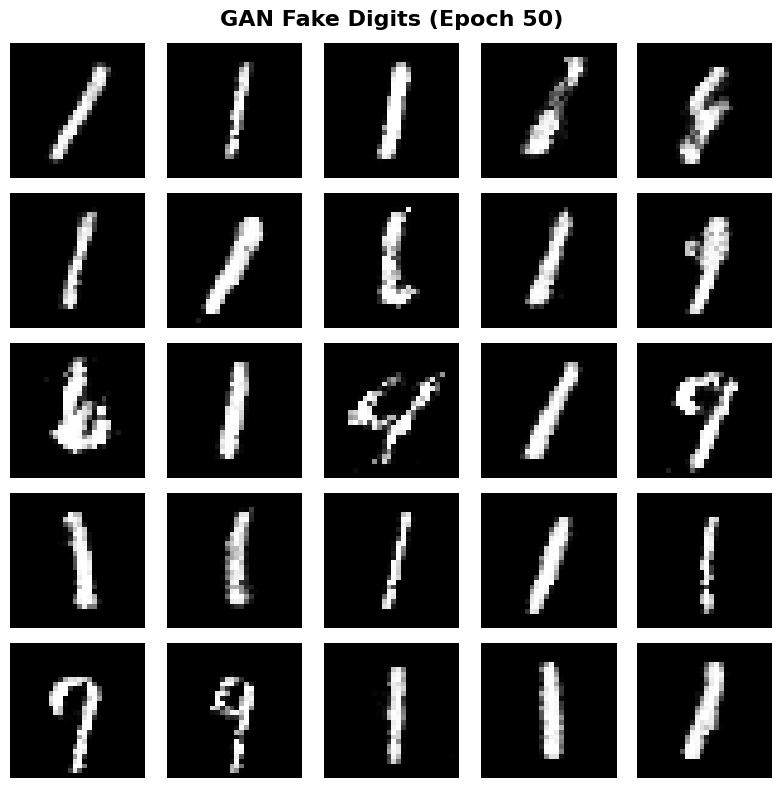

In [ ]:
import matplotlib.pyplot as plt

generator.eval() # 도둑아, 이제 연습 끝났다. 실전 모드 켜라!

with torch.no_grad():
    # 1. 100차원의 무작위 노이즈 25개 생성 (빈 도화지 25장 준비)
    z = torch.randn(25, 100).to(device)

    # 2. 위조지폐범에게 던져서 그림을 상상하게 함!
    generated_imgs = generator(z).cpu()

# 3. 25장의 그림을 5x5 격자로 전시하기
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    # 784개의 1차원 픽셀을 다시 28x28 2차원 이미지로 접기
    plt.imshow(generated_imgs[i].view(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("GAN Fake Digits (Epoch 50)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

VAE와 다르게 흐릿해 보이진 않지만, 뚝뚝 픽셀 단위로 끊어져 보임 : '픽셀레이션(Pixelation)'
이는 nn.Linear가 784개의 픽셀을 그냥 일렬로 길게 늘어선 '독립된 숫자 784개'로 취급하기에 위 아래 정보와 이어지는 공간적 연결성을 보장하지 못하기 때문에 발생함

-->

'DCGAN' (Deep Convolutional GAN)
이 부품은 이미지를 1차원으로 쫙 펴지 않고, 2차원 네모 모양 그대로 다룹니다.

"아, 내 이웃 픽셀들이 다 하얀색이구나? 그럼 나도 하얀색으로 자연스럽게 이어져야지!"라며 주변 픽셀과의 관계를 고려해서 그림을 그리게 됩니다.

In [ ]:
import torch.nn as nn

# 1. 2D 위조지폐범 (Generator)
class DCGenerator(nn.Module):
    def __init__(self):
        super(DCGenerator, self).__init__()
        self.main = nn.Sequential(
            # ① 100차원 노이즈 -> 128장짜리 7x7 미니 도화지로 변환
            nn.Linear(100, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (128, 7, 7)), # ⭐️ 핵심: 1차원을 3차원(채널, 높이, 너비)으로 입체화! : Unflattetn

            # ② 7x7 -> 14x14로 2배 부드럽게 확대 (ConvTranspose2d: 확대경 역할 : 역합성곱 )
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            # Kernel (4): 돋보기(또는 도장)의 크기가 4x4 픽셀이라는 뜻,
            # Stride (2): 돋보기를 한 번에 2칸씩 껑충껑충 건너뛰며 이동시킨다는 뜻입니다. (이것 때문에 크기가 정확히 절반으로 줄거나, 2배로 커집니다!)
            # Padding (1): 이미지 테두리에 빈 공간을 1칸씩 덧대어 줍니다.
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # ③ 14x14 -> 28x28로 2배 확대 & 최종 흑백 픽셀(1채널)로 압축
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() # 아까 쓰던 DataLoader를 그대로 쓰기 위해 0.0 ~ 1.0으로 맞춤
        )

    def forward(self, z):
        return self.main(z)

# 2. 2D 경찰 (Discriminator)
class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.main = nn.Sequential(
            # ① 28x28 이미지 -> 14x14로 축소 (Conv2d: 축소경 역할 : 합성곱)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # ② 14x14 -> 7x7로 축소
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # ③ 남은 특징들을 쫙 펴서 1개의 진짜/가짜 확률값으로 만들기 : Flatten
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.main(img)

In [ ]:
import torch.optim as optim

# 1. 새로운 2D 선수들 링 위로 입장!
dc_generator = DCGenerator().to(device)
dc_discriminator = DCDiscriminator().to(device)

# 심판 모셔오기
criterion = nn.BCELoss()

# 2. 전담 코치 배정 (⭐️ 황금 밸런스 패치 + DCGAN 전용 betas 치트키 적용!)
# lr은 아까처럼 경찰(0.0001)이 도둑(0.0002)보다 눈치가 느리게 세팅했습니다.
G_optimizer = optim.Adam(dc_generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
D_optimizer = optim.Adam(dc_discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

num_epochs = 20 # 20번만 돌아도 충분히 선명해집니다!
latent_dim = 100

print("🚀 2D 공간을 다루는 DCGAN 훈련을 시작합니다! (연산량이 많아 조금 더 걸립니다)")

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)

        # ⭐️ 핵심 변화: .view(-1, 784)가 사라졌습니다!
        # (batch_size, 1, 28, 28) 형태의 2차원 이미지를 그대로 GPU에 올립니다.
        real_images = real_images.to(device)

        # 밸런스 패치: 라벨 스무딩 (0.9)
        real_labels = torch.full((batch_size, 1), 0.9).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ==========================================
        # 🥊 1라운드: 2D 경찰(Discriminator) 훈련
        # ==========================================
        D_optimizer.zero_grad()

        # 진짜 이미지 채점 (돋보기 슥슥)
        outputs = dc_discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        # 도둑이 가짜 이미지 생성 (스탬프 쾅쾅)
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = dc_generator(z)

        # 가짜 이미지 채점
        outputs = dc_discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        D_optimizer.step()

        # ==========================================
        # 🥊 2라운드: 2D 위조지폐범(Generator) 훈련
        # ==========================================
        G_optimizer.zero_grad()

        # 경찰 속이기
        outputs = dc_discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        G_optimizer.step()

    # 출력 결과 확인
    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | 경찰 Loss: {d_loss.item():.4f} | 도둑 Loss: {g_loss.item():.4f}")

🚀 2D 공간을 다루는 DCGAN 훈련을 시작합니다! (연산량이 많아 조금 더 걸립니다)
Epoch [01/20] | 경찰 Loss: 0.6801 | 도둑 Loss: 1.7810
Epoch [02/20] | 경찰 Loss: 0.6162 | 도둑 Loss: 2.2621
Epoch [03/20] | 경찰 Loss: 0.8764 | 도둑 Loss: 0.7365
Epoch [04/20] | 경찰 Loss: 0.6224 | 도둑 Loss: 1.6033
Epoch [05/20] | 경찰 Loss: 0.6453 | 도둑 Loss: 1.7970
Epoch [06/20] | 경찰 Loss: 0.6234 | 도둑 Loss: 1.9959
Epoch [07/20] | 경찰 Loss: 0.7078 | 도둑 Loss: 1.4457
Epoch [08/20] | 경찰 Loss: 0.6836 | 도둑 Loss: 1.6071
Epoch [09/20] | 경찰 Loss: 0.6254 | 도둑 Loss: 1.9661
Epoch [10/20] | 경찰 Loss: 0.7162 | 도둑 Loss: 2.1997
Epoch [11/20] | 경찰 Loss: 1.0308 | 도둑 Loss: 0.8243
Epoch [12/20] | 경찰 Loss: 0.8504 | 도둑 Loss: 1.1299
Epoch [13/20] | 경찰 Loss: 0.7078 | 도둑 Loss: 2.0474
Epoch [14/20] | 경찰 Loss: 0.6858 | 도둑 Loss: 1.8665
Epoch [15/20] | 경찰 Loss: 0.5703 | 도둑 Loss: 2.6001
Epoch [16/20] | 경찰 Loss: 0.7017 | 도둑 Loss: 1.2533
Epoch [17/20] | 경찰 Loss: 0.7003 | 도둑 Loss: 1.4169
Epoch [18/20] | 경찰 Loss: 0.5645 | 도둑 Loss: 2.1220
Epoch [19/20] | 경찰 Loss: 0.6516 | 도둑 Loss: 2.1175


컴퓨터 비전의 꽃인 CNN(합성곱)을 장착했더니, 단 20번(Epoch) 만에 이렇게 완벽한 수치가 나왔습니다.

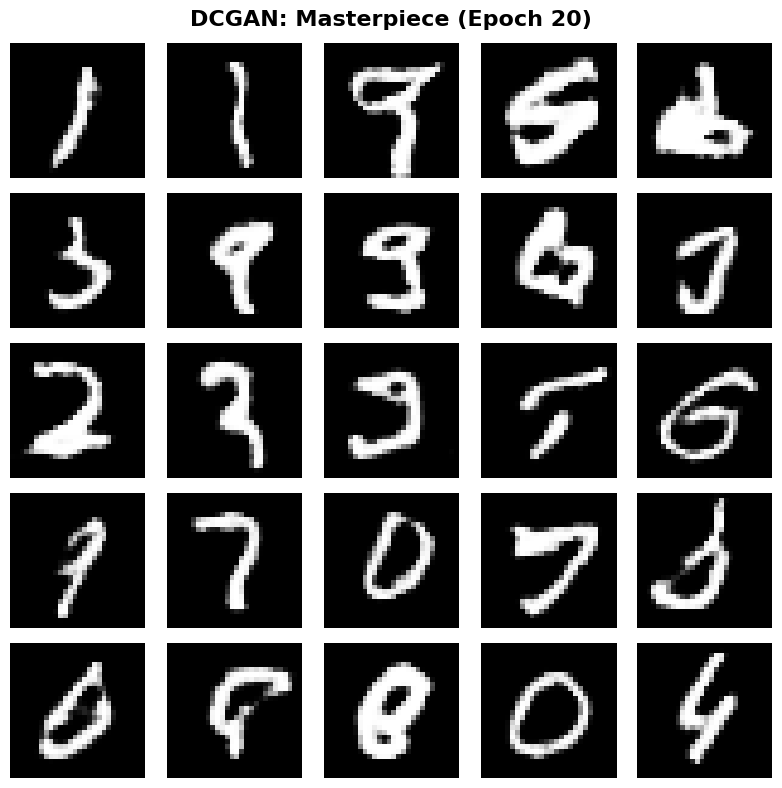

In [ ]:
import matplotlib.pyplot as plt

dc_generator.eval() # 도둑아, 스탬프 준비해라! 실전이다!

with torch.no_grad():
    # 1. 100차원의 무작위 노이즈 25개 생성
    z = torch.randn(25, 100).to(device)

    # 2. 2D 위조지폐범에게 던져서 그림 생성!
    # 출력 형태는 이미 완벽한 (25장, 1채널, 28가로, 28세로) 입니다.
    generated_imgs = dc_generator(z).cpu()

# 3. 25장의 그림 전시하기
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    # 아까처럼 .view(28, 28)로 억지로 접을 필요가 없습니다!
    # .squeeze()를 써서 불필요한 '1채널' 껍데기만 살짝 벗겨줍니다.
    plt.imshow(generated_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("DCGAN: Masterpiece (Epoch 20)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

pixelation 사라진건지 애매해서 블라인드 테스트 시작

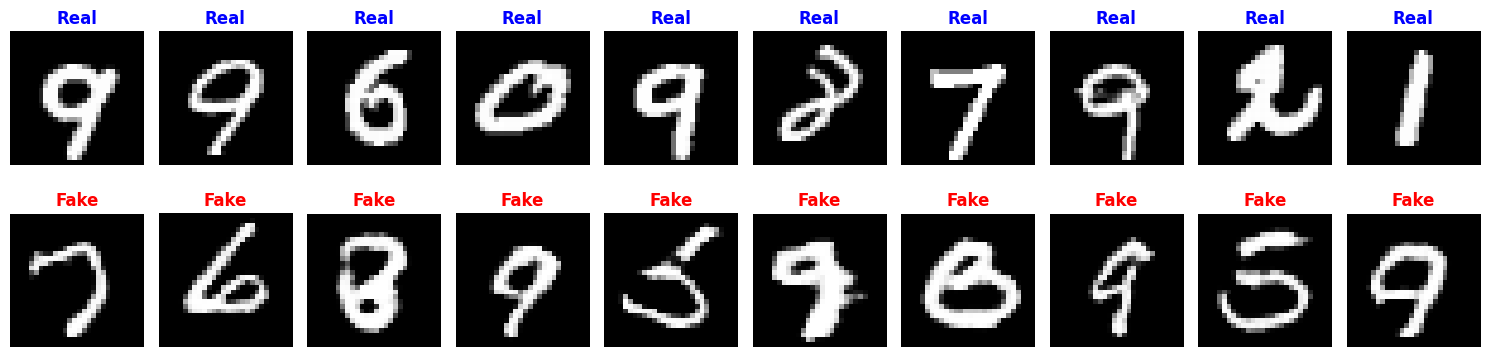

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. 컨베이어 벨트에서 '진짜 정답지' 한 박스 가져오기
real_batch = next(iter(train_loader))
real_imgs = real_batch[0][:10] # 10장만 쏙 빼옵니다

# 2. '가짜 정답지' 10장 새로 그리기
dc_generator.eval()
with torch.no_grad():
    z = torch.randn(10, 100).to(device)
    fake_imgs = dc_generator(z).cpu()

# 3. 전시회장 세팅 (위쪽 10개: 진짜 / 아래쪽 10개: 가짜)
plt.figure(figsize=(15, 4))

# 진짜(Real) 이미지 전시
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(real_imgs[i].squeeze(), cmap='gray')
    plt.title("Real", color='blue', fontweight='bold')
    plt.axis('off')

# 가짜(Fake) 이미지 전시
for i in range(10):
    plt.subplot(2, 10, i + 11)
    plt.imshow(fake_imgs[i].squeeze(), cmap='gray')
    plt.title("Fake", color='red', fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

아마 진짜 데이터조차도 28x28이라는 작은 픽셀 크기 때문에 테두리가 부드럽지 않고 레고 블록처럼 계단 현상(픽셀레이션)이 있다는 걸 발견하실 겁니다.

 위조지폐범은 그저 "아, 정답지 테두리가 원래 이렇게 우둘투둘하게 생겼구나!" 하고 그 픽셀의 느낌까지 완벽하게 베껴버린 거죠!